In [ ]:
# ============================================
# Step 1: Import Required Libraries
# ============================================

import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision
import torchvision.transforms as transforms

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# ============================================
# Step 2: Check GPU
# ============================================

import torch

print("PyTorch Version:", torch.__version__)

if torch.cuda.is_available():
    print("GPU Available")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU Not Available")

PyTorch Version: 2.11.0+cu128
GPU Available
GPU Name: Tesla T4


In [ ]:
# ============================================
# Step 3: Extract Dataset
# ============================================

zip_path = "/content/archive (3).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [ ]:
# ============================================
# Step 4: Check Dataset Structure
# ============================================

for root, dirs, files in os.walk(extract_path):
    print(root)

/content/dataset
/content/dataset/combined_images
/content/dataset/combined_images/ModerateDemented
/content/dataset/combined_images/NonDemented
/content/dataset/combined_images/VeryMildDemented
/content/dataset/combined_images/MildDemented


In [ ]:
# ============================================
# Step 5: Count Images in Each Class
# ============================================

dataset_path = "/content/dataset/combined_images"

classes = os.listdir(dataset_path)

print("=" * 50)
print("Dataset Summary")
print("=" * 50)

total_images = 0

for cls in sorted(classes):
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        total_images += count

        print(f"{cls:20s} : {count} images")

print("=" * 50)
print(f"Total Images : {total_images}")

Dataset Summary
MildDemented         : 10000 images
ModerateDemented     : 10000 images
NonDemented          : 12800 images
VeryMildDemented     : 11200 images
Total Images : 44000


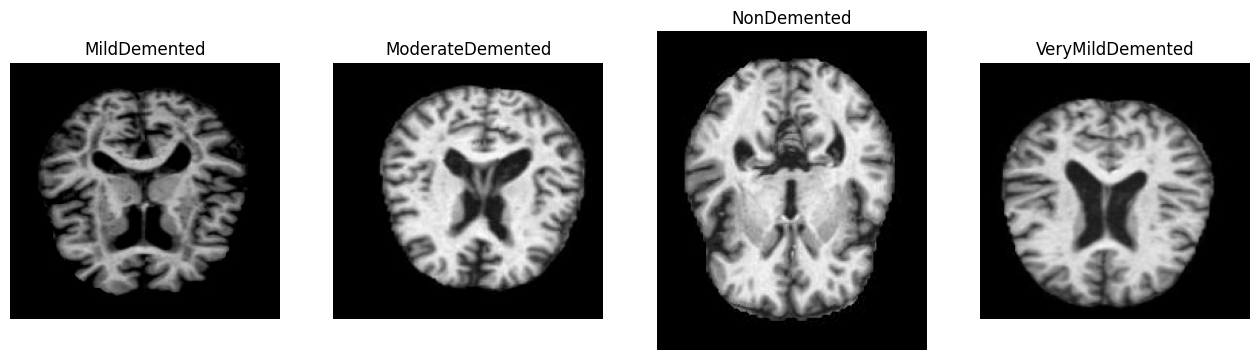

In [ ]:
# ============================================
# Step 6: Display Sample Images
# ============================================

import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(1, 4, figsize=(16,5))

for i, cls in enumerate(sorted(classes)):

    class_path = os.path.join(dataset_path, cls)

    image_name = random.choice(os.listdir(class_path))

    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.show()

In [ ]:
# ============================================
# Step 7 : Data Preprocessing
# ============================================

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import random_split, DataLoader

# Image Transformations
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

dataset = datasets.ImageFolder(
    root="/content/dataset/combined_images",
    transform=transform
)

print("Dataset Loaded Successfully")
print("Total Images :", len(dataset))
print("Number of Classes :", len(dataset.classes))
print("Classes :", dataset.classes)

Dataset Loaded Successfully
Total Images : 44000
Number of Classes : 4
Classes : ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [ ]:
# ============================================
# Step 8 : Train Validation Test Split
# ============================================

train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Testing Images :", len(test_dataset))

Training Images : 30799
Validation Images : 6600
Testing Images : 6601


In [ ]:
# ============================================
# Step 9 : Data Loaders
# ============================================

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoaders Created Successfully!")

DataLoaders Created Successfully!


In [ ]:
# ============================================
# Step 10 : Build Baseline CNN Model
# ============================================

import torch
import torch.nn as nn

class BaselineCNN(nn.Module):

    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256*14*14,512),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512,4)

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

model = BaselineCNN()

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=4, bias=True)
  )


In [ ]:
# ============================================
# Step 11 : Move Model to GPU
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Device :", device)

Device : cuda


In [ ]:
# ============================================
# Step 12 : Loss Function and Optimizer
# ============================================

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Loss Function and Optimizer Ready")

Loss Function and Optimizer Ready


In [ ]:
# ============================================
# Step 13 : Train Baseline CNN
# ============================================

from tqdm import tqdm

num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        progress_bar.set_description(
            f"Epoch [{epoch+1}/{num_epochs}]"
        )

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"\nEpoch {epoch+1}")
    print(f"Loss : {epoch_loss:.4f}")
    print(f"Accuracy : {epoch_accuracy:.2f}%")

Epoch [1/10]: 100%|██████████| 963/963 [02:24<00:00,  6.65it/s]



Epoch 1
Loss : 0.9169
Accuracy : 57.49%


Epoch [2/10]: 100%|██████████| 963/963 [02:23<00:00,  6.73it/s]



Epoch 2
Loss : 0.5546
Accuracy : 76.01%


Epoch [3/10]: 100%|██████████| 963/963 [02:22<00:00,  6.78it/s]


...


Epoch 8
Loss : 0.0811
Accuracy : 96.95%


Epoch [9/10]: 100%|██████████| 963/963 [02:23<00:00,  6.72it/s]



Epoch 9
Loss : 0.0707
Accuracy : 97.38%


Epoch [10/10]: 100%|██████████| 963/963 [02:21<00:00,  6.81it/s]


Epoch 10
Loss : 0.0558
Accuracy : 97.99%


In [ ]:
# ============================================
# Step 14 : Evaluate CNN Model
# ============================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_predictions)

print("="*50)
print(f"Test Accuracy : {accuracy*100:.2f}%")
print("="*50)

print("\nClassification Report\n")
print(classification_report(all_labels, all_predictions))

Test Accuracy : 93.73%

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1425
           1       0.99      1.00      0.99      1506
           2       0.96      0.91      0.93      1923
           3       0.91      0.91      0.91      1747

    accuracy                           0.94      6601
   macro avg       0.94      0.94      0.94      6601
weighted avg       0.94      0.94      0.94      6601



<Figure size 800x800 with 0 Axes>

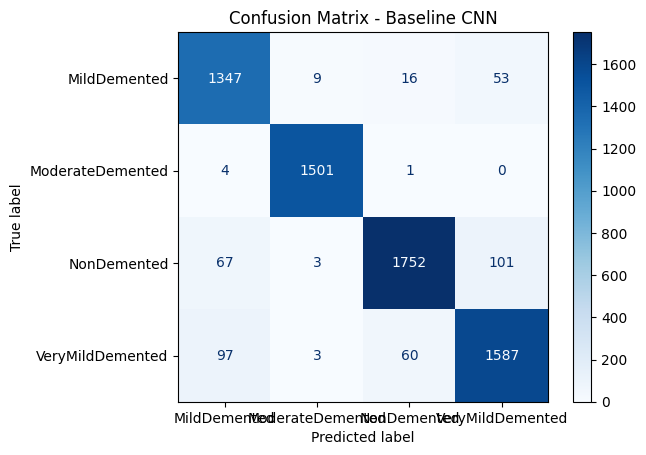

In [ ]:
# ============================================
# Step 15 : Confusion Matrix
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

plt.figure(figsize=(8,8))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Baseline CNN")
plt.show()

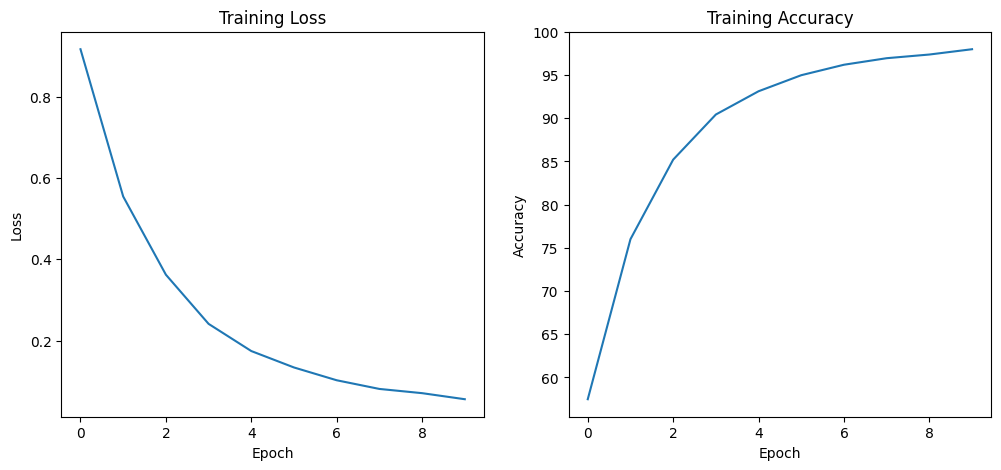

In [ ]:
# ============================================
# Step 16 : Training Curves
# ============================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
# ============================================
# Step 17 : Load ResNet50
# ============================================

import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet50
model_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Replace final layer
model_resnet.fc = nn.Linear(
    model_resnet.fc.in_features,
    4
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_resnet = model_resnet.to(device)

print(model_resnet)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 90.9MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# ============================================
# Step 18 : Loss and Optimizer
# ============================================

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_resnet.parameters(),
    lr=0.0001
)

print("ResNet50 Ready")

ResNet50 Ready


In [ ]:
# ============================================
# Step 19 : Train ResNet50
# ============================================

from tqdm import tqdm

epochs = 5

train_loss_resnet = []
train_acc_resnet = []

for epoch in range(epochs):

    model_resnet.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_resnet(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_loss_resnet.append(epoch_loss)
    train_acc_resnet.append(epoch_acc)

    print(f"Epoch {epoch+1}")
    print(f"Loss : {epoch_loss:.4f}")
    print(f"Accuracy : {epoch_acc:.2f}%")

100%|██████████| 963/963 [06:51<00:00,  2.34it/s]


Epoch 1
Loss : 0.3261
Accuracy : 86.64%


100%|██████████| 963/963 [06:46<00:00,  2.37it/s]


Epoch 2
Loss : 0.0512
Accuracy : 98.27%


100%|██████████| 963/963 [06:46<00:00,  2.37it/s]


Epoch 3
Loss : 0.0333
Accuracy : 98.90%


100%|██████████| 963/963 [06:46<00:00,  2.37it/s]


Epoch 4
Loss : 0.0245
Accuracy : 99.14%


100%|██████████| 963/963 [06:46<00:00,  2.37it/s]

Epoch 5
Loss : 0.0210
Accuracy : 99.35%


In [ ]:
# ============================================
# Step 20 : Evaluate ResNet50
# ============================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_resnet.eval()

all_predictions_resnet = []
all_labels_resnet = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_resnet(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions_resnet.extend(predicted.cpu().numpy())
        all_labels_resnet.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels_resnet, all_predictions_resnet)

print("="*50)
print(f"Test Accuracy : {accuracy*100:.2f}%")
print("="*50)

print("\nClassification Report\n")
print(classification_report(all_labels_resnet, all_predictions_resnet))

Test Accuracy : 98.82%

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1425
           1       1.00      1.00      1.00      1506
           2       0.98      0.99      0.99      1923
           3       0.98      0.98      0.98      1747

    accuracy                           0.99      6601
   macro avg       0.99      0.99      0.99      6601
weighted avg       0.99      0.99      0.99      6601



<Figure size 800x800 with 0 Axes>

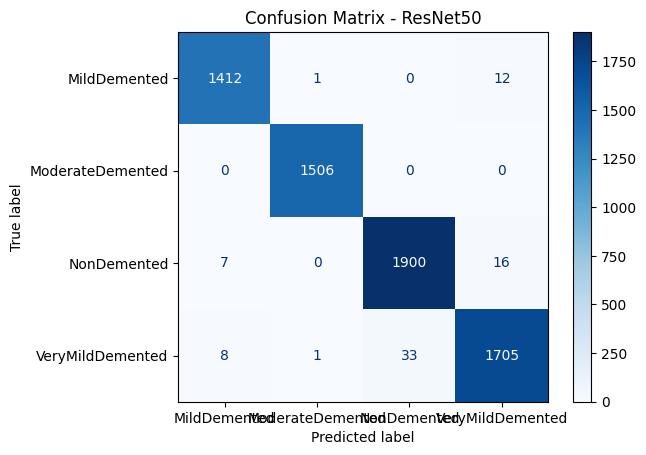

In [ ]:
# ============================================
# Step 21 : Confusion Matrix
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels_resnet, all_predictions_resnet)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

plt.figure(figsize=(8,8))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - ResNet50")
plt.show()

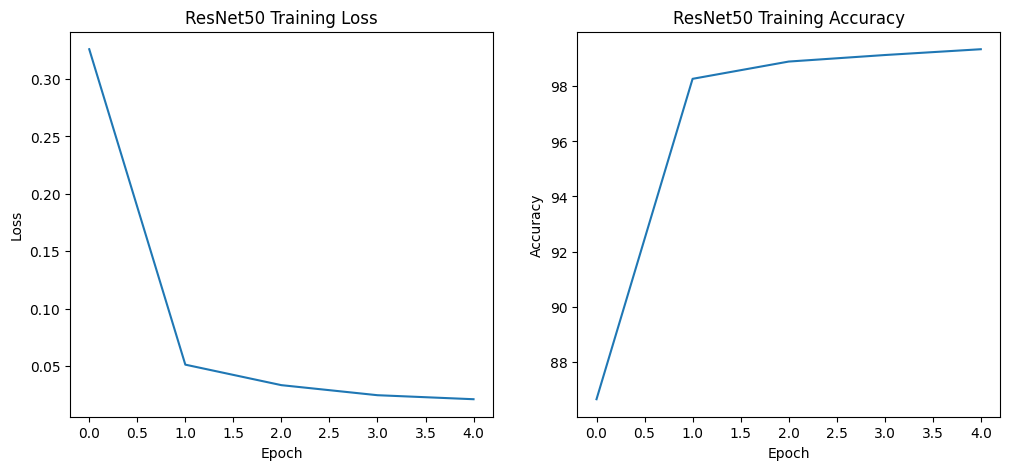

In [ ]:
# ============================================
# Step 22 : ResNet50 Training Curves
# ============================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss_resnet)
plt.title("ResNet50 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_acc_resnet)
plt.title("ResNet50 Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
# ============================================
# Step 20 : Evaluate ResNet50
# ============================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

model_resnet.eval()

all_predictions_resnet = []
all_labels_resnet = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_resnet(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions_resnet.extend(predicted.cpu().numpy())
        all_labels_resnet.extend(labels.cpu().numpy())

accuracy_resnet = accuracy_score(
    all_labels_resnet,
    all_predictions_resnet
)

print("="*60)
print("ResNet50 Test Accuracy :", round(accuracy_resnet*100,2),"%")
print("="*60)

print(classification_report(
    all_labels_resnet,
    all_predictions_resnet,
    target_names=dataset.classes
))

ResNet50 Test Accuracy : 98.82 %
                  precision    recall  f1-score   support

    MildDemented       0.99      0.99      0.99      1425
ModerateDemented       1.00      1.00      1.00      1506
     NonDemented       0.98      0.99      0.99      1923
VeryMildDemented       0.98      0.98      0.98      1747

        accuracy                           0.99      6601
       macro avg       0.99      0.99      0.99      6601
    weighted avg       0.99      0.99      0.99      6601



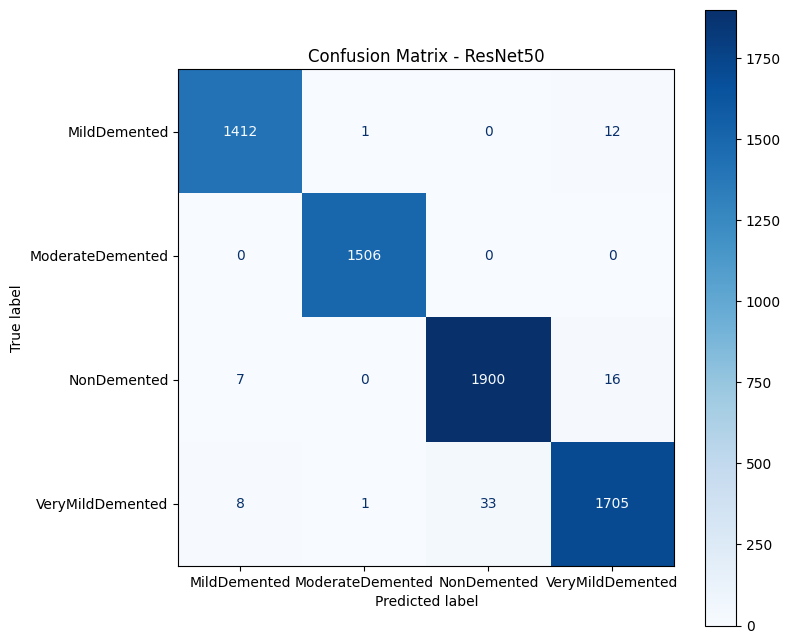

In [ ]:
# ============================================
# Step 21 : Confusion Matrix
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels_resnet,
    all_predictions_resnet
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("Confusion Matrix - ResNet50")
plt.show()

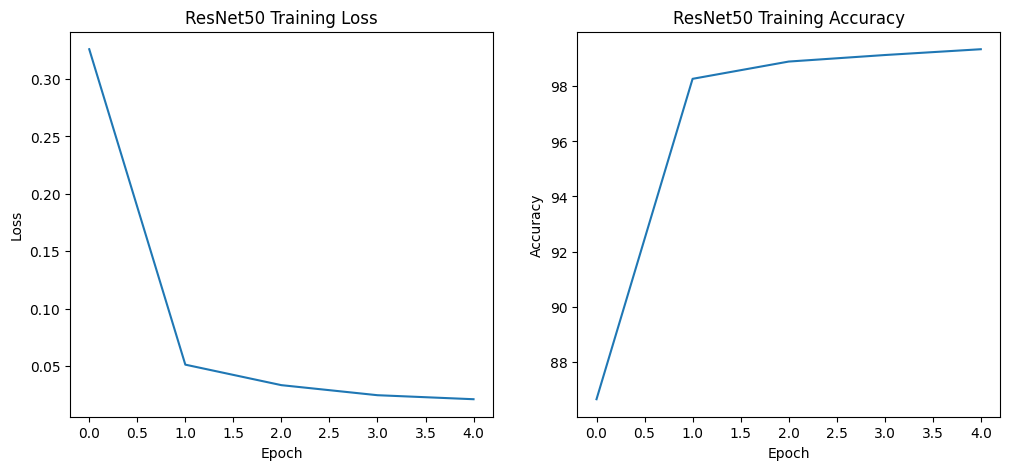

In [ ]:
# ============================================
# Step 22 : Training Curves
# ============================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(train_loss_resnet)

plt.title("ResNet50 Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.subplot(1,2,2)

plt.plot(train_acc_resnet)

plt.title("ResNet50 Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()